In [22]:
import numpy as np
import matplotlib.pyplot as plt
from part_1.controller import DPController, simulate_error_dynamics

# Parameter tuning

In [23]:
def plot_simulation_results(results):
    """
    GEMINI MADE THIS
    Plots position errors, velocity errors, and actuator usage in 3 vertical subplots.
    """
    t = results["time"]
    x = results["state_error"]
    u = results["actuator_usage"]

    # Extract states # and DO NOT convert angles to degrees
    ex, ey, epsi = x[0], x[1], np.rad2deg(x[2])  # x[2]
    eu, ev, er = x[3], x[4], np.rad2deg(x[5])  # x[5]

    # Extract actuator usage and convert to kN and kN·m
    tau_x, tau_y, tau_psi = u[0] / 1000, u[1] / 1000, u[2] / 1000

    # Create 3 vertical subplots sharing the x-axis
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, dpi=100)

    # --- Plot 1: Position / Heading Errors ---
    axes[0].plot(t, ex, label=r"$e_x$ [m]", linewidth=2)
    axes[0].plot(t, ey, label=r"$e_y$ [m]", linewidth=2)
    axes[0].plot(t, epsi, label=r"$e_\psi$ [deg]", linewidth=2, linestyle="--")
    axes[0].axhline(0, color="black", linestyle=":", alpha=0.6)
    axes[0].set_title("Position and Heading Errors")
    axes[0].set_ylabel("Error")
    axes[0].grid(True, linestyle="--", alpha=0.7)
    axes[0].legend()

    # --- Plot 2: Velocity Errors ---
    axes[1].plot(t, eu, label=r"$e_u$ [m/s]", linewidth=2)
    axes[1].plot(t, ev, label=r"$e_v$ [m/s]", linewidth=2)
    axes[1].plot(t, er, label=r"$e_r$ [deg/s]", linewidth=2, linestyle="--")
    axes[1].axhline(0, color="black", linestyle=":", alpha=0.6)
    axes[1].set_title("Velocity Errors")
    axes[1].set_ylabel("Error")
    axes[1].grid(True, linestyle="--", alpha=0.7)
    axes[1].legend()

    # --- Plot 3: Actuator Usage ---
    axes[2].plot(t, tau_x, label=r"$\tau_x$ [kN]", linewidth=2)
    axes[2].plot(t, tau_y, label=r"$\tau_y$ [kN]", linewidth=2)
    axes[2].plot(t, tau_psi, label=r"$\tau_\psi$ [kN·m]", linewidth=2, linestyle="--")
    axes[2].axhline(0, color="black", linestyle=":", alpha=0.6)
    axes[2].set_title("Actuator Usage (Control Input)")
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel("Force / Moment")
    axes[2].grid(True, linestyle="--", alpha=0.7)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_scalar_metrics(scalar_metrics_dict):
    """
    GEMINI MADE THIS
    Plots single-number performance metrics (IAE, ISE) as bar charts.
    """
    n_metrics = len(scalar_metrics_dict)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(12, 3.5 * n_metrics), dpi=100)

    if n_metrics == 1:
        axes = [axes]

    state_labels = [r"$e_x$", r"$e_y$", r"$e_\psi$", r"$e_u$", r"$e_v$", r"$e_r$"]

    for ax, (metric_name, metric_values) in zip(axes, scalar_metrics_dict.items()):
        bars = ax.bar(state_labels, metric_values, color="skyblue", edgecolor="black")

        for bar in bars:
            yval = bar.get_height()
            val_str = f"{yval:.2e}" if yval > 1e4 or yval < 1e-2 else f"{yval:.2f}"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                yval,
                val_str,
                ha="center",
                va="bottom",
                fontsize=9,
            )

        ax.set_title(f"Performance Metric: {metric_name}")
        ax.set_ylabel("Metric Value")
        ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()


def plot_timeseries_metrics(time_array, ts_metrics_dict):
    """
    GEMINI MADE THIS
    Plots cumulative performance metrics as continuous time series.
    """
    n_metrics = len(ts_metrics_dict)
    fig, axes = plt.subplots(
        n_metrics, 1, figsize=(12, 3 * n_metrics), sharex=True, dpi=100
    )

    if n_metrics == 1:
        axes = [axes]

    labels = [r"$e_x$", r"$e_y$", r"$e_\psi$", r"$e_u$", r"$e_v$", r"$e_r$"]
    linestyles = ["-", "-", "-", "--", "--", "--"]

    for ax, (metric_name, metric_data) in zip(axes, ts_metrics_dict.items()):
        for i in range(6):
            ax.plot(
                time_array,
                metric_data[i, :],
                label=labels[i],
                linestyle=linestyles[i],
                linewidth=2,
            )

        ax.set_title(f"{metric_name} Over Time")
        ax.set_ylabel("Metric Value")
        ax.grid(True, linestyle="--", alpha=0.7)
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()

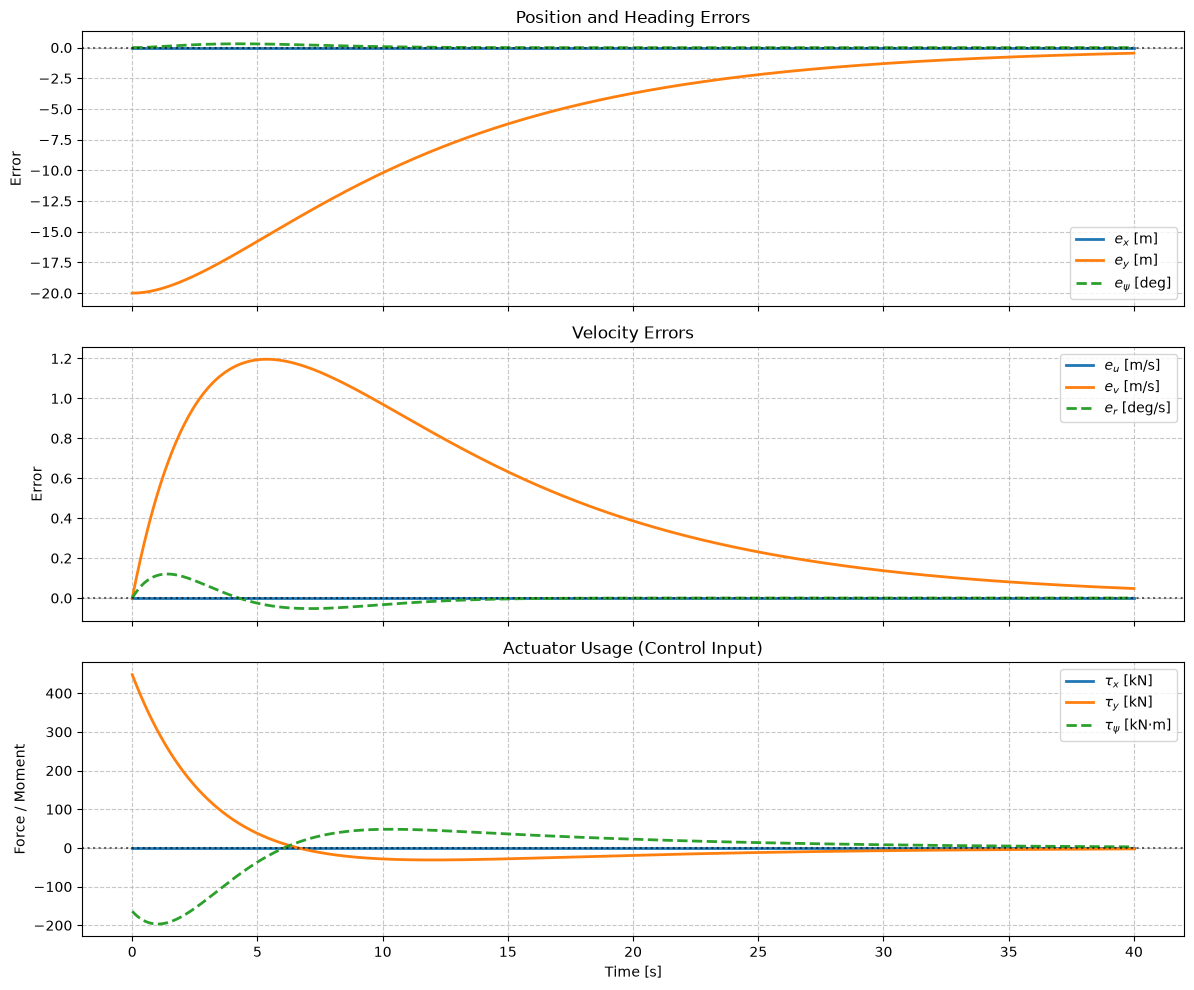

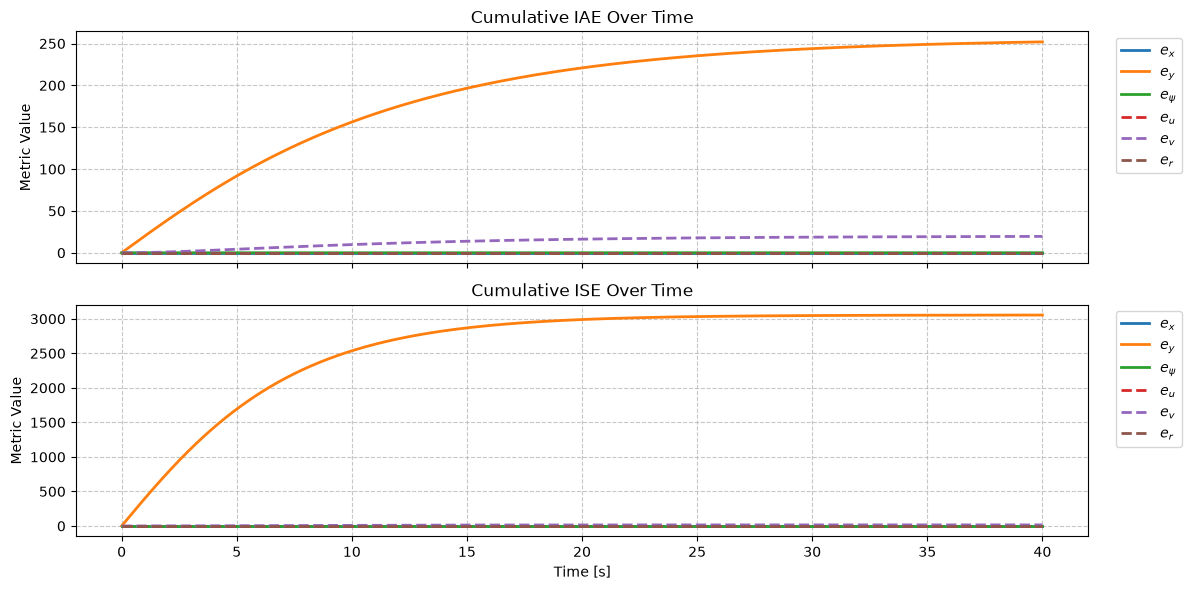

In [24]:
controller = DPController()

x0_surge = 0  # m
x0_sway = -20  # m
x0_yaw = 0 * np.pi / 180  # rad
x0_vel_surge = 0  # m/s
x0_vel_sway = 0  # m/s
x0_vel_yaw = 0 * np.pi /180   # rad/s


x0 = np.array([x0_surge, x0_sway, x0_yaw, x0_vel_surge, x0_vel_sway, x0_vel_yaw])

# --- Usage ---
# print(f"IAE for Position X: {results['metrics']['IAE'][0]:.2f}")
# print(f"ISE for Position Y: {results['metrics']['ISE'][1]:.2f}")
# 1. Run simulation
results = simulate_error_dynamics(controller, x0, t_end=40)

time = results["time"]
ex, ey, epsi = results["state_error"][0:3]
tau_x, tau_y, tau_psi = results["actuator_usage"]

# 2. Plot states and actuators (using your existing plot_simulation_results function)
plot_simulation_results(results)

# # 3. Create a dictionary for scalar metrics and plot
# scalar_dict = {"IAE": results["metrics"]["IAE"], "ISE": results["metrics"]["ISE"]}
# plot_scalar_metrics(scalar_dict)

# 4. Create a dictionary for time-series metrics and plot
ts_dict = {
    "Cumulative IAE": results["metrics"]["Cumulative IAE"],
    "Cumulative ISE": results["metrics"]["Cumulative ISE"],
}
plot_timeseries_metrics(results["time"], ts_dict)